# **Customer Churn Prediction (Classification)**

## **Problem Statement**
Customer churn is a major concern for businesses, especially in industries like telecom,
banking, and SaaS. Losing customers leads to revenue loss and increased acquisition costs.

In this project, the goal is to build a Machine Learning classification model that predicts
whether a customer will leave the company (Churn: Yes/No) based on features

## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Load Dataset**

In [2]:
data = pd.read_csv("telecom_churn_data.csv")
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## **Basic Checks**

In [3]:
data.shape

(7043, 21)

In [5]:
print(data.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [4]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


In [6]:
data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7038 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7041 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7041.000000
mean,0.162147,32.371149,64.749581
std,0.368612,24.559481,30.085731
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
print(data.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [9]:
cat_cols = data.select_dtypes(include='object')
cat_cols

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,1889.5,No
2,3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes
3,7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),1840.75,No
4,9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,NaN,Electronic check,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,1990.5,No
7039,2234-XADUH,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),7362.9,No
7040,4801-JZAZL,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,346.45,No
7041,8361-LTMKD,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,306.6,Yes


In [10]:
num_col = data.select_dtypes(include=['int64','float64'])
num_col

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70
...,...,...,...
7038,0,24,84.80
7039,0,72,103.20
7040,0,11,29.60
7041,1,4,74.40


In [11]:
for x in cat_cols.drop(columns='customerID'):
  print(x,'-->',data[x].unique())

gender --> ['Female' 'Male' nan]
Partner --> ['Yes' 'No']
Dependents --> ['No' 'Yes']
PhoneService --> ['No' 'Yes']
MultipleLines --> ['No phone service' 'No' 'Yes']
InternetService --> ['DSL' 'Fiber optic' 'No']
OnlineSecurity --> ['No' 'Yes' 'No internet service']
OnlineBackup --> ['Yes' 'No' 'No internet service']
DeviceProtection --> ['No' 'Yes' 'No internet service']
TechSupport --> ['No' 'Yes' 'No internet service']
StreamingTV --> ['No' 'Yes' 'No internet service']
StreamingMovies --> ['No' 'Yes' 'No internet service']
Contract --> ['Month-to-month' 'One year' 'Two year']
PaperlessBilling --> ['Yes' 'No' nan]
PaymentMethod --> ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges --> ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
Churn --> ['No' 'Yes']


In [12]:
for x in cat_cols.drop(columns='customerID'):
  print(data[x].value_counts())
  print()

gender
Male      3550
Female    3488
Name: count, dtype: int64

Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

StreamingTV
No                 

## **Handle Missing values**

In [13]:
print(data.isnull().sum())

customerID          0
gender              5
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    2
PaymentMethod       0
MonthlyCharges      2
TotalCharges        5
Churn               0
dtype: int64


In [14]:
data.duplicated().sum()

np.int64(0)

**Gender**

In [15]:
data.loc[:,'gender'].dtypes

dtype('O')

In [16]:
data.loc[:,'gender'].mode()[0]

'Male'

In [17]:
data.loc[:,'gender']=data.loc[:,'gender'].fillna(data.loc[:,'gender'].mode()[0])

**PaperlessBilling**

In [18]:
data.loc[:,'PaperlessBilling'].dtypes

dtype('O')

In [19]:
data.loc[:,'PaperlessBilling'].mode()[0]

'Yes'

In [20]:
data.loc[:,'PaperlessBilling']=data.loc[:,'PaperlessBilling'].fillna(data.loc[:,'PaperlessBilling'].mode()[0])

**MonthlyCharges**

In [21]:
data.loc[:,'MonthlyCharges'].dtypes

dtype('float64')

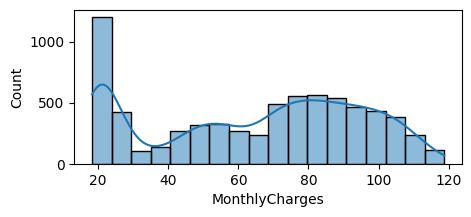

In [22]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='MonthlyCharges',kde=True)
plt.show()

In [23]:
data.loc[:,'MonthlyCharges'].skew()

np.float64(-0.22028439456532767)

In [24]:
data.loc[:,'MonthlyCharges'].median()

70.35

In [25]:
data.loc[:,'MonthlyCharges']=data.loc[:,'MonthlyCharges'].fillna(data.loc[:,'MonthlyCharges'].median())

**TotalCharges**

In [26]:
data.loc[:,'TotalCharges'].dtypes

dtype('O')

In [27]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [28]:
data.loc[:,'TotalCharges'].dtypes

dtype('float64')

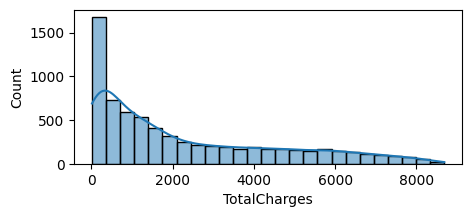

In [29]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='TotalCharges',kde=True)
plt.show()

In [30]:
data.loc[:,'TotalCharges'].skew()

np.float64(0.9616058347613503)

In [31]:
data.loc[:,'TotalCharges'].median()

1397.3

In [32]:
data.loc[:,'TotalCharges']=data.loc[:,'TotalCharges'].fillna(data.loc[:,'TotalCharges'].median())

In [33]:
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [34]:
num_cols = data.select_dtypes(include=['int64','float64'])
num_cols

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65
...,...,...,...,...
7038,0,24,84.80,1990.50
7039,0,72,103.20,7362.90
7040,0,11,29.60,346.45
7041,1,4,74.40,306.60


In [35]:
data.drop(columns={'customerID'},inplace=True)

## **Univariate Analysis**
* Distribution of numerical features
* Count plots for categorical features

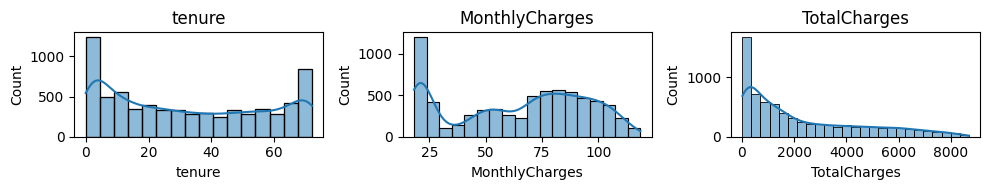

In [36]:
num_cols1 = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(10,2))
for i, col in enumerate(num_cols1, 1):
    plt.subplot(1, 3, i)  # 1 row, 3 columns
    sns.histplot(data[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

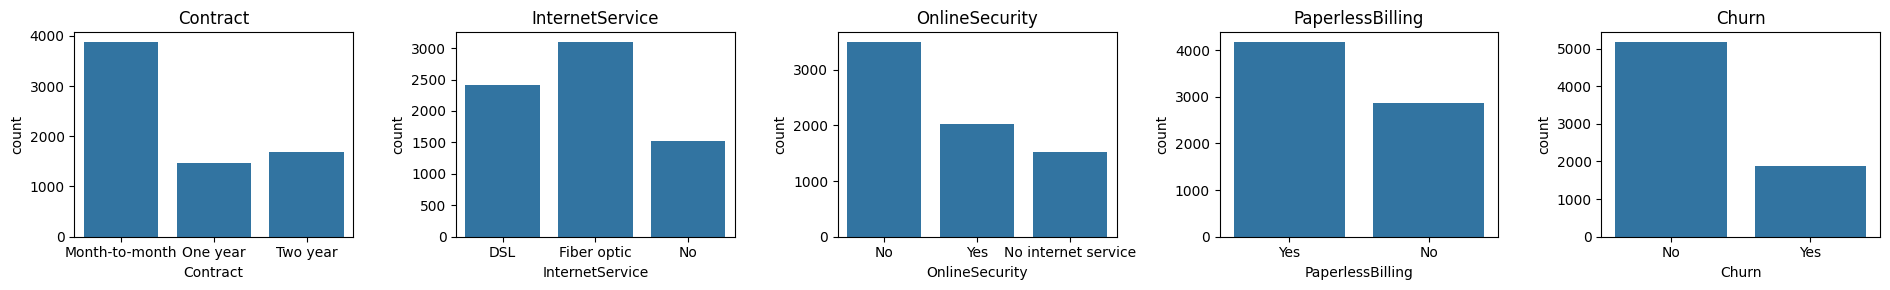

In [37]:
cat_cols1 = ['Contract','InternetService','OnlineSecurity','PaperlessBilling','Churn']
plt.figure(figsize=(19,3))
for i, col in enumerate(cat_cols1, 1):
    plt.subplot(1, 5, i)   # 1 row, 5 columns
    sns.countplot(data=data, x=col)
    plt.title(col)

plt.tight_layout()
plt.show()


## **Bivariate Analysis**

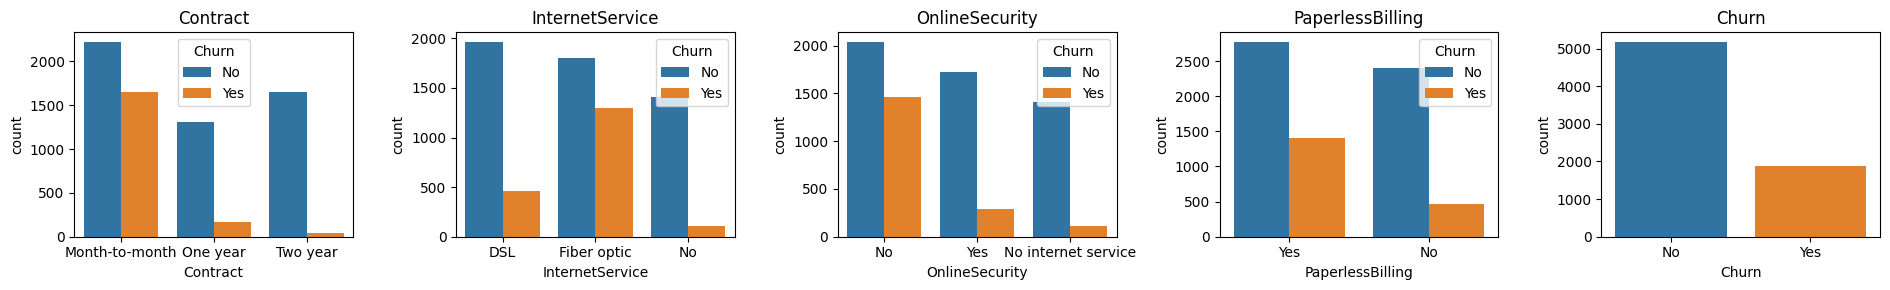

In [38]:
cat_cols1 = ['Contract','InternetService','OnlineSecurity','PaperlessBilling','Churn']
plt.figure(figsize=(19,3))
for i, col in enumerate(cat_cols1, 1):
    plt.subplot(1, 5, i)   # 1 row, 5 columns
    sns.countplot(data,x=col, hue='Churn')
    plt.title(col)
plt.tight_layout()
plt.show()

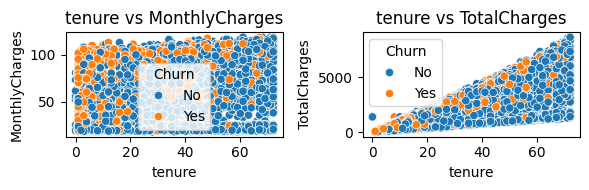

In [39]:
num_cols2 = ['MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(6,2))
for i, col in enumerate(num_cols2, 1):
    plt.subplot(1, 2, i)   # 1 row, 2 columns
    sns.scatterplot(data=data, x='tenure', y=col, hue='Churn')
    plt.title(f'tenure vs {col}')
plt.tight_layout()
plt.show()

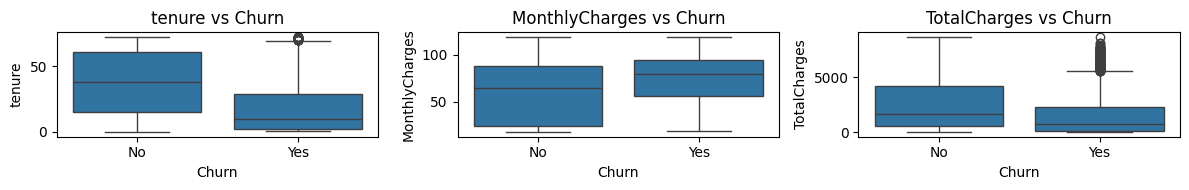

In [40]:
num_cols1 = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(12,2))
for i, col in enumerate(num_cols1, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=data, x='Churn', y=col)
    plt.title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

## **Correlation Heatmap**

In [41]:
num_cols.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.219901,0.102759
tenure,0.016567,1.000000,0.247712,0.825339
MonthlyCharges,0.219901,0.247712,1.000000,0.650435
TotalCharges,0.102759,0.825339,0.650435,1.000000


<Axes: >

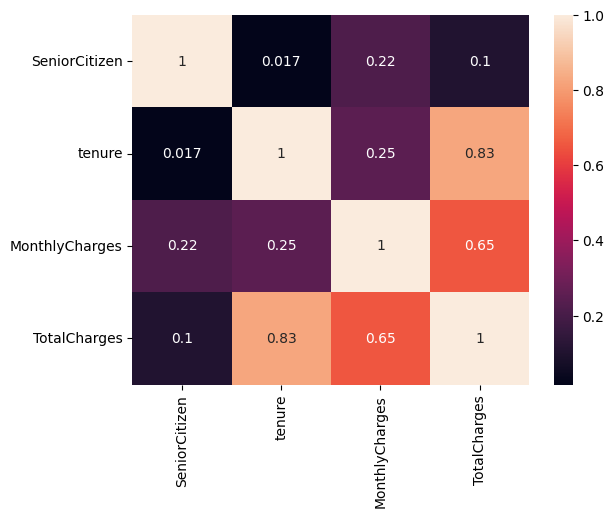

In [42]:
sns.heatmap(num_cols.corr(),annot=True)

## **Handling Outliers**

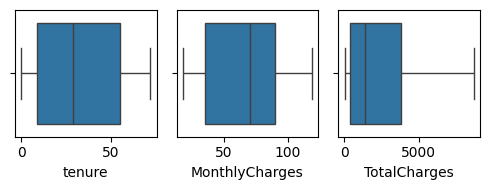

In [43]:
fig,ax = plt.subplots(1,3,figsize=(5,2))
sns.boxplot(data,x='tenure',ax=ax[0])
sns.boxplot(data,x='MonthlyCharges',ax=ax[1])
sns.boxplot(data,x='TotalCharges',ax=ax[2])
plt.tight_layout()

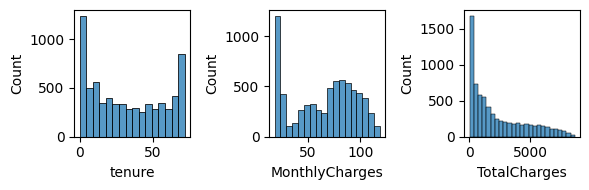

In [44]:
fig,ax = plt.subplots(1,3,figsize=(6,2))
sns.histplot(data,x='tenure',ax=ax[0])
sns.histplot(data,x='MonthlyCharges',ax=ax[1])
sns.histplot(data,x='TotalCharges',ax=ax[2])
plt.tight_layout()

In [45]:
A =['tenure',	'MonthlyCharges', 'TotalCharges']
for x in A:
  print(data[x].skew())

0.2395397495619829
-0.22046922813679604
0.9647294463449093


In [46]:
Q1 = data.loc[:,'TotalCharges'].quantile(0.25)
Q3 = data.loc[:,'TotalCharges'].quantile(0.75)
IQR = Q3-Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit= Q3 + 1.5*IQR

In [47]:
# filter all the values greater than upper and less than lower
data[(data.loc[:,'TotalCharges']>upper_limit)|(data.loc[:,'TotalCharges']<lower_limit)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [48]:
# %
len(data[(data.loc[:,'TotalCharges']>upper_limit)|(data.loc[:,'TotalCharges']<lower_limit)])/len(data)*100

0.0

In [49]:
mean_val = data.loc[:,'tenure'].mean()
std_val = data.loc[:,'tenure'].std()
lower_limit = mean_val - 3* std_val
upper_limit = mean_val + 3* std_val

In [50]:
# filter all the values greater than upper and less than lower
data[(data.loc[:,'tenure']>upper_limit)|(data.loc[:,'tenure']<lower_limit)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [51]:
# %
len(data[(data.loc[:,'tenure']>upper_limit)|(data.loc[:,'tenure']<lower_limit)])/len(data)*100

0.0

In [52]:
mean_val = data.loc[:,'MonthlyCharges'].mean()
std_val = data.loc[:,'MonthlyCharges'].std()
lower_limit = mean_val - 3* std_val
upper_limit = mean_val + 3* std_val

In [53]:
# filter all the values greater than upper and less than lower
data[(data.loc[:,'MonthlyCharges']>upper_limit)|(data.loc[:,'MonthlyCharges']<lower_limit)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [54]:
# %
len(data[(data.loc[:,'MonthlyCharges']>upper_limit)|(data.loc[:,'MonthlyCharges']<lower_limit)])/len(data)*100

0.0

## **Encoding**

In [55]:
print(data.dtypes)

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [56]:
for x in cat_cols.drop(columns='customerID'):
  print(x,'-->',data[x].unique())

gender --> ['Female' 'Male']
Partner --> ['Yes' 'No']
Dependents --> ['No' 'Yes']
PhoneService --> ['No' 'Yes']
MultipleLines --> ['No phone service' 'No' 'Yes']
InternetService --> ['DSL' 'Fiber optic' 'No']
OnlineSecurity --> ['No' 'Yes' 'No internet service']
OnlineBackup --> ['Yes' 'No' 'No internet service']
DeviceProtection --> ['No' 'Yes' 'No internet service']
TechSupport --> ['No' 'Yes' 'No internet service']
StreamingTV --> ['No' 'Yes' 'No internet service']
StreamingMovies --> ['No' 'Yes' 'No internet service']
Contract --> ['Month-to-month' 'One year' 'Two year']
PaperlessBilling --> ['Yes' 'No']
PaymentMethod --> ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges --> [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn --> ['No' 'Yes']


In [57]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data.loc[:,'partner']=le.fit_transform(data.loc[:,'Partner'])
data.loc[:,'dependents']=le.fit_transform(data.loc[:,'Dependents'])
data.loc[:,'Phone_Service']=le.fit_transform(data.loc[:,'PhoneService'])
data.loc[:,'Paperless_Billing']=le.fit_transform(data.loc[:,'PaperlessBilling'])
data.loc[:,'churn']=le.fit_transform(data.loc[:,'Churn'])

In [58]:
cols = ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in cols:
    data[col] = data[col].replace({
        'No internet service':0,
        'No phone service':0,
        'No':1,
        'Yes':2
    })

/tmp/ipykernel_31803/4246858082.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].replace({


In [59]:
onehot_cols = ['gender','InternetService', 'Contract', 'PaymentMethod']
data = pd.get_dummies(data, columns=onehot_cols,dtype='int', drop_first=True)

In [60]:
data.drop(columns={'Churn','Partner','Dependents','PhoneService','PaperlessBilling'},inplace=True)

In [61]:
print(data.dtypes)

SeniorCitizen                              int64
tenure                                     int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
MonthlyCharges                           float64
TotalCharges                             float64
partner                                    int64
dependents                                 int64
Phone_Service                              int64
Paperless_Billing                          int64
churn                                      int64
gender_Male                                int64
InternetService_Fiber optic                int64
InternetService_No                         int64
Contract_One year                          int64
Contract_Two year   

## **Scaling**

In [62]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data[['tenure']]=scaler.fit_transform(data[['tenure']])
data[['MonthlyCharges']]=scaler.fit_transform(data[['MonthlyCharges']])
data[['TotalCharges']]=scaler.fit_transform(data[['TotalCharges']])

In [63]:
data

,SeniorCitizen,tenure,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MonthlyCharges,...,Paperless_Billing,churn,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-1.277445,0,1,2,1,1,1,1,-1.160299,...,1,0,0,0,0,0,0,0,1,0
1,0,0.066327,1,2,1,2,1,1,1,-0.259352,...,0,0,1,0,0,1,0,0,0,1
2,0,-1.236724,1,2,2,1,1,1,1,-0.362412,...,1,1,1,0,0,0,0,0,0,1
3,0,0.514251,0,2,1,2,2,1,1,-0.746395,...,0,0,1,0,0,1,0,0,0,0
4,0,-1.236724,1,1,1,1,1,1,1,0.197770,...,1,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,-0.340876,2,2,1,2,2,2,2,0.666529,...,1,0,1,0,0,1,0,0,0,1
7039,0,1.613701,2,1,2,2,1,2,2,1.278242,...,1,0,0,1,0,1,0,1,0,0
7040,0,-0.870241,0,2,1,1,1,1,1,-1.168610,...,1,0,0,0,0,0,0,0,1,0
7041,1,-1.155283,2,1,1,1,1,1,1,0.320778,...,1,1,1,1,0,0,0,0,0,1


## **Split data for x and y**

In [64]:
x=data.drop(columns=['churn'])
y= data.loc[:,'churn']

In [65]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

## **Balancing data**

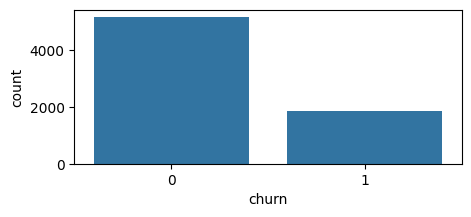

In [66]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='churn')
plt.show()

In [67]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE()
x_sampled,y_sampled = smote.fit_resample(x_train,y_train)

In [68]:
Counter(y_train)

Counter({0: 4138, 1: 1496})

In [69]:
Counter(y_sampled)

Counter({0: 4138, 1: 4138})

# Logistic Regression

In [80]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(x_sampled,y_sampled)
y_pred = log_model.predict(x_test)

In [81]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score,roc_auc_score
print("confusion matrix\n", confusion_matrix(y_test,y_pred))
print("Accuracy: " ,accuracy_score(y_test,y_pred))
print('Recall: ',recall_score(y_test,y_pred))
print('Precision: ',precision_score(y_test,y_pred))
print('f1_score: ',f1_score(y_test,y_pred))

confusion matrix
 [[787 249]
 [ 82 291]]
Accuracy:  0.7650816181689141
Recall:  0.7801608579088471
Precision:  0.5388888888888889
f1_score:  0.6374589266155531


# KNN Classifier

In [82]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(x_sampled,y_sampled)
y_pred_1 = knn_model.predict(x_test)

In [83]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred_1))
print("Accuracy: " ,accuracy_score(y_test,y_pred_1))
print('Recall: ',recall_score(y_test,y_pred_1))
print('Precision: ',precision_score(y_test,y_pred_1))
print('f1_score: ',f1_score(y_test,y_pred_1))

confusion matrix
 [[710 326]
 [ 73 300]]
Accuracy:  0.716820440028389
Recall:  0.8042895442359249
Precision:  0.4792332268370607
f1_score:  0.6006006006006006


# **Decision Tree Classifier**

In [84]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(x_sampled,y_sampled)
y_pred_2 = dt_model.predict(x_test)

In [85]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred_2))
print("Accuracy: " ,accuracy_score(y_test,y_pred_2))
print('Recall: ',recall_score(y_test,y_pred_2))
print('Precision: ',precision_score(y_test,y_pred_2))
print('f1_score: ',f1_score(y_test,y_pred_2))

confusion matrix
 [[788 248]
 [158 215]]
Accuracy:  0.7118523775727467
Recall:  0.5764075067024129
Precision:  0.46436285097192226
f1_score:  0.5143540669856459


In [86]:
from sklearn.tree import DecisionTreeClassifier
dt_tuned_model = DecisionTreeClassifier(criterion='gini',
                               max_depth=50,max_features='sqrt',
                               splitter='best',min_samples_leaf=5,
                               min_samples_split=6,random_state=42)
dt_tuned_model.fit(x_sampled,y_sampled)
y_pred_2a = dt_tuned_model.predict(x_test)

In [87]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred_2a))
print("Accuracy: " ,accuracy_score(y_test,y_pred_2a))
print('Recall: ',recall_score(y_test,y_pred_2a))
print('Precision: ',precision_score(y_test,y_pred_2a))
print('f1_score: ',f1_score(y_test,y_pred_2a))

confusion matrix
 [[778 258]
 [129 244]]
Accuracy:  0.7253371185237757
Recall:  0.6541554959785523
Precision:  0.4860557768924303
f1_score:  0.5577142857142857


# Random Forest Classifier

In [88]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(x_sampled,y_sampled)
y_pred_3 = rf_model.predict(x_test)

In [89]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred_3))
print("Accuracy: " ,accuracy_score(y_test,y_pred_3))
print('Recall: ',recall_score(y_test,y_pred_3))
print('Precision: ',precision_score(y_test,y_pred_3))
print('f1_score: ',f1_score(y_test,y_pred_3))

confusion matrix
 [[854 182]
 [126 247]]
Accuracy:  0.7814052519517388
Recall:  0.6621983914209115
Precision:  0.5757575757575758
f1_score:  0.6159600997506235


In [90]:
from sklearn.ensemble import RandomForestClassifier
rf_tuned_model = RandomForestClassifier(n_estimators=10,max_depth=50,
                               bootstrap=True,criterion='gini',
                               max_features='sqrt',min_samples_split=6,
                               min_samples_leaf=5,random_state=30)
rf_tuned_model.fit(x_sampled,y_sampled)
y_pred_3r = rf_tuned_model.predict(x_test)

In [91]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred_3r))
print("Accuracy: " ,accuracy_score(y_test,y_pred_3r))
print('Recall: ',recall_score(y_test,y_pred_3r))
print('Precision: ',precision_score(y_test,y_pred_3r))
print('f1_score: ',f1_score(y_test,y_pred_3r))

confusion matrix
 [[827 209]
 [ 97 276]]
Accuracy:  0.7828246983676366
Recall:  0.739946380697051
Precision:  0.5690721649484536
f1_score:  0.6433566433566433


# Gradient Boosting

In [92]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier()
gb_model.fit(x_sampled,y_sampled)
y_pred_4 = gb_model.predict(x_test)

In [93]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred_4))
print("Accuracy: " ,accuracy_score(y_test,y_pred_4))
print('Recall: ',recall_score(y_test,y_pred_4))
print('Precision: ',precision_score(y_test,y_pred_4))
print('f1_score: ',f1_score(y_test,y_pred_4))

confusion matrix
 [[797 239]
 [ 80 293]]
Accuracy:  0.7735982966643009
Recall:  0.7855227882037533
Precision:  0.5507518796992481
f1_score:  0.6475138121546962


In [94]:
from sklearn.ensemble import GradientBoostingClassifier
gb_tuned_model = GradientBoostingClassifier(n_estimators=10,max_depth=60,
                               learning_rate=0.01,
                               max_features='sqrt',min_samples_split=6,
                               min_samples_leaf=5,random_state=20)
gb_tuned_model.fit(x_sampled,y_sampled)
y_pred_4g = gb_tuned_model.predict(x_test)

In [95]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred_4g))
print("Accuracy: " ,accuracy_score(y_test,y_pred_4g))
print('Recall: ',recall_score(y_test,y_pred_4g))
print('Precision: ',precision_score(y_test,y_pred_4g))
print('f1_score: ',f1_score(y_test,y_pred_4g))

confusion matrix
 [[828 208]
 [105 268]]
Accuracy:  0.7778566359119943
Recall:  0.7184986595174263
Precision:  0.5630252100840336
f1_score:  0.6313309776207303


# XGBOOST Classifier

In [96]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier()
xgb_model.fit(x_sampled,y_sampled)
y_pred_5 = xgb_model.predict(x_test)

In [97]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred_5))
print("Accuracy: " ,accuracy_score(y_test,y_pred_5))
print('Recall: ',recall_score(y_test,y_pred_5))
print('Precision: ',precision_score(y_test,y_pred_5))
print('f1_score: ',f1_score(y_test,y_pred_5))

confusion matrix
 [[841 195]
 [130 243]]
Accuracy:  0.7693399574166075
Recall:  0.6514745308310992
Precision:  0.5547945205479452
f1_score:  0.5992601726263872


In [98]:
from xgboost import XGBClassifier
xgb_tuned_model = XGBClassifier(n_estimators=50,max_depth=10,
                      learning_rate=0.1, gamma=0.1,subsample=0.8,
                      colsample_bytree=0.8,reg_alpha =0.1 ,
                      reg_lambda=1,n_jobs=-1)
xgb_tuned_model.fit(x_sampled,y_sampled)
y_pred_5x = xgb_tuned_model.predict(x_test)

In [99]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred_5x))
print("Accuracy: " ,accuracy_score(y_test,y_pred_5x))
print('Recall: ',recall_score(y_test,y_pred_5x))
print('Precision: ',precision_score(y_test,y_pred_5x))
print('f1_score: ',f1_score(y_test,y_pred_5x))

confusion matrix
 [[839 197]
 [115 258]]
Accuracy:  0.7785663591199432
Recall:  0.6916890080428955
Precision:  0.567032967032967
f1_score:  0.6231884057971014


# Support Vector Classifier

In [100]:
from sklearn.svm import SVC
svc_model = SVC(probability=True) # Set probability=True for ROC AUC
svc_model.fit(x_sampled,y_sampled)
y_pred_6 = svc_model.predict(x_test)

In [101]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred_6))
print("Accuracy: " ,accuracy_score(y_test,y_pred_6))
print('Recall: ',recall_score(y_test,y_pred_6))
print('Precision: ',precision_score(y_test,y_pred_6))
print('f1_score: ',f1_score(y_test,y_pred_6))

confusion matrix
 [[794 242]
 [ 88 285]]
Accuracy:  0.765791341376863
Recall:  0.7640750670241286
Precision:  0.540796963946869
f1_score:  0.6333333333333333


In [102]:
from sklearn.svm import SVC
svc_tuned_model = SVC(kernel ='rbf',gamma=0.01,C=20, probability=True)
svc_tuned_model.fit(x_sampled,y_sampled)
y_pred_6s = svc_tuned_model.predict(x_test)

In [103]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred_6s))
print("Accuracy: " ,accuracy_score(y_test,y_pred_6s))
print('Recall: ',recall_score(y_test,y_pred_6s))
print('Precision: ',precision_score(y_test,y_pred_6s))
print('f1_score: ',f1_score(y_test,y_pred_6s))

confusion matrix
 [[789 247]
 [ 77 296]]
Accuracy:  0.7700496806245565
Recall:  0.7935656836461126
Precision:  0.5451197053406999
f1_score:  0.6462882096069869


In [104]:
y_prob_log = log_model.predict_proba(x_test)[:,1]
y_prob_1 = knn_model.predict_proba(x_test)[:,1]
y_prob_2a = dt_model.predict_proba(x_test)[:,1]
y_prob_3r = rf_model.predict_proba(x_test)[:,1]
y_prob_4g = gb_model.predict_proba(x_test)[:,1]
y_prob_5x = xgb_model.predict_proba(x_test)[:,1]
y_prob_6s = svc_tuned_model.predict_proba(x_test)[:,1]

In [105]:
from sklearn.metrics import roc_auc_score
print("Logistic ROC:", roc_auc_score(y_test, y_prob_log))
print("Decision Tree (Tuned) ROC:", roc_auc_score(y_test, y_prob_2a))
print("Random Forest (Tuned) ROC:", roc_auc_score(y_test, y_prob_3r))
print("KNN ROC:", roc_auc_score (y_test, y_prob_1))
print("Gradient Boosting (Tuned) ROC:", roc_auc_score(y_test, y_prob_4g))
print("XGBoost (Tuned) ROC:", roc_auc_score(y_test, y_prob_5x))
print("SVC (Tuned) ROC:", roc_auc_score(y_test, y_prob_6s))

Logistic ROC: 0.8504986698686429
Decision Tree (Tuned) ROC: 0.6681037605970583
Random Forest (Tuned) ROC: 0.8362799797116152
KNN ROC: 0.8042235552289172
Gradient Boosting (Tuned) ROC: 0.8530334240790004
XGBoost (Tuned) ROC: 0.8282319086608632
SVC (Tuned) ROC: 0.8513578208618422


# **Grid Search CV**

In [106]:
from sklearn.model_selection import GridSearchCV
svc_gs_model = SVC(probability=True)
parameters = {'kernel':['rbf'],'gamma':[0.01,0.1],'C':[10]}
grid = GridSearchCV(estimator=svc_gs_model,param_grid=parameters,cv=2,scoring='accuracy',n_jobs=-1)
grid.fit(x_sampled,y_sampled)
svc_gs_model = grid.best_estimator_

In [107]:
print(grid.best_params_)

{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [108]:
from sklearn.svm import SVC
model = SVC(kernel ='rbf',gamma=0.1,C=10, probability=True)
model.fit(x_sampled,y_sampled)
y_pred_g = svc_gs_model.predict(x_test)

In [109]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred_g))
print("Accuracy: " ,accuracy_score(y_test,y_pred_g))
print('Recall: ',recall_score(y_test,y_pred_g))
print('Precision: ',precision_score(y_test,y_pred_g))
print('f1_score: ',f1_score(y_test,y_pred_g))

confusion matrix
 [[789 247]
 [101 272]]
Accuracy:  0.7530163236337828
Recall:  0.7292225201072386
Precision:  0.5240847784200385
f1_score:  0.6098654708520179


# **Randomised Search CV**

In [110]:
from sklearn.model_selection import RandomizedSearchCV
svc_rs_model = SVC(probability=True)
parameters = {'kernel':['rbf'],
              'gamma':[0.01,0.1],
              'C':[10]}
random = RandomizedSearchCV(n_iter=5,estimator=svc_rs_model ,cv=5,
                            param_distributions=parameters,scoring='accuracy',n_jobs=-1)
random.fit(x_sampled,y_sampled)
svc_rs_model = random.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=5. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [111]:
print(random.best_params_)

{'kernel': 'rbf', 'gamma': 0.1, 'C': 10}


In [112]:
from sklearn.svm import SVC
model = SVC(kernel ='rbf',gamma=0.1,C=10, probability=True)
model.fit(x_sampled,y_sampled)
y_pred_r = svc_rs_model.predict(x_test)

In [113]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred_r))
print("Accuracy: " ,accuracy_score(y_test,y_pred_r))
print('Recall: ',recall_score(y_test,y_pred_r))
print('Precision: ',precision_score(y_test,y_pred_r))
print('f1_score: ',f1_score(y_test,y_pred_r))

confusion matrix
 [[789 247]
 [101 272]]
Accuracy:  0.7530163236337828
Recall:  0.7292225201072386
Precision:  0.5240847784200385
f1_score:  0.6098654708520179


# Grid Search CV for XGboost


In [114]:
model = XGBClassifier()
parameters = {'max_depth':[3,5,7],'n_estimators':[50,100],
              'learning_rate':[0.1,0.2],'reg_alpha':[0.1],
              'reg_lambda':[0.1]}
grid = GridSearchCV(estimator=model,param_grid=parameters,cv= 3,scoring='accuracy',n_jobs=-1)
grid.fit(x_sampled,y_sampled)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.2], 'max_depth': [3, 5, 7],
                         'n_estimators': [50, 100], 'reg_alpha': [0.1],
                         'reg_lambda': [0.1]},
             scoring='accuracy')

In [115]:
print(grid.best_params_)

{'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 50, 'reg_alpha': 0.1, 'reg_lambda': 0.1}


# MLP Classifier

In [116]:
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier()
mlp_model.fit(x_sampled,y_sampled)
y_pred_m = mlp_model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [117]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred_m))
print("Accuracy: " ,accuracy_score(y_test,y_pred_m))
print('Recall: ',recall_score(y_test,y_pred_m))
print('Precision: ',precision_score(y_test,y_pred_m))
print('f1_score: ',f1_score(y_test,y_pred_m))

confusion matrix
 [[826 210]
 [108 265]]
Accuracy:  0.7743080198722498
Recall:  0.710455764075067
Precision:  0.5578947368421052
f1_score:  0.625


In [118]:
from sklearn.neural_network import MLPClassifier
mlp_tuned_model = MLPClassifier(hidden_layer_sizes=(20,20),activation='relu',solver='adam',random_state=42)
mlp_tuned_model.fit(x_sampled,y_sampled)
y_pred_hm = mlp_tuned_model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [119]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred_hm))
print("Accuracy: " ,accuracy_score(y_test,y_pred_hm))
print('Recall: ',recall_score(y_test,y_pred_hm))
print('Precision: ',precision_score(y_test,y_pred_hm))
print('f1_score: ',f1_score(y_test,y_pred_hm))

confusion matrix
 [[770 266]
 [ 97 276]]
Accuracy:  0.7423704755145494
Recall:  0.739946380697051
Precision:  0.5092250922509225
f1_score:  0.6032786885245902


## **Comparision Model**

In [120]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic": (y_pred, y_prob_log),
    "KNN": (y_pred_1, y_prob_1),
    "Decision Tree": (y_pred_2a, y_prob_2a),
    "Random Forest": (y_pred_3r, y_prob_3r),
    "Gradient Boosting": (y_pred_4g, y_prob_4g),
    "XGBoost": (y_pred_5x, y_prob_5x),
    "SVC": (y_pred_6s, y_prob_6s)
}

for name, (y_pred, y_prob) in models.items():

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print("MODEL:", name)
    print("Accuracy:", acc)
    print("Precision:", pre)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("ROC-AUC:", auc)
    print("----------------------------")

MODEL: Logistic
Accuracy: 0.7650816181689141
Precision: 0.5388888888888889
Recall: 0.7801608579088471
F1 Score: 0.6374589266155531
ROC-AUC: 0.8504986698686429
----------------------------
MODEL: KNN
Accuracy: 0.716820440028389
Precision: 0.4792332268370607
Recall: 0.8042895442359249
F1 Score: 0.6006006006006006
ROC-AUC: 0.8042235552289172
----------------------------
MODEL: Decision Tree
Accuracy: 0.7253371185237757
Precision: 0.4860557768924303
Recall: 0.6541554959785523
F1 Score: 0.5577142857142857
ROC-AUC: 0.6681037605970583
----------------------------
MODEL: Random Forest
Accuracy: 0.7828246983676366
Precision: 0.5690721649484536
Recall: 0.739946380697051
F1 Score: 0.6433566433566433
ROC-AUC: 0.8362799797116152
----------------------------
MODEL: Gradient Boosting
Accuracy: 0.7778566359119943
Precision: 0.5630252100840336
Recall: 0.7184986595174263
F1 Score: 0.6313309776207303
ROC-AUC: 0.8530334240790004
----------------------------
MODEL: XGBoost
Accuracy: 0.7785663591199432
Prec

**Based on the F1 Score,ROC-AUC and Recall Score , the SVC model performed the best with an F1 Score of 0.6462,ROC-AUC score of 0.8513 and Recall score of 0.7935.This indicates a good balance between precision and recall for predicting customer churn**

## **Feature Importance Plot (SVC)**

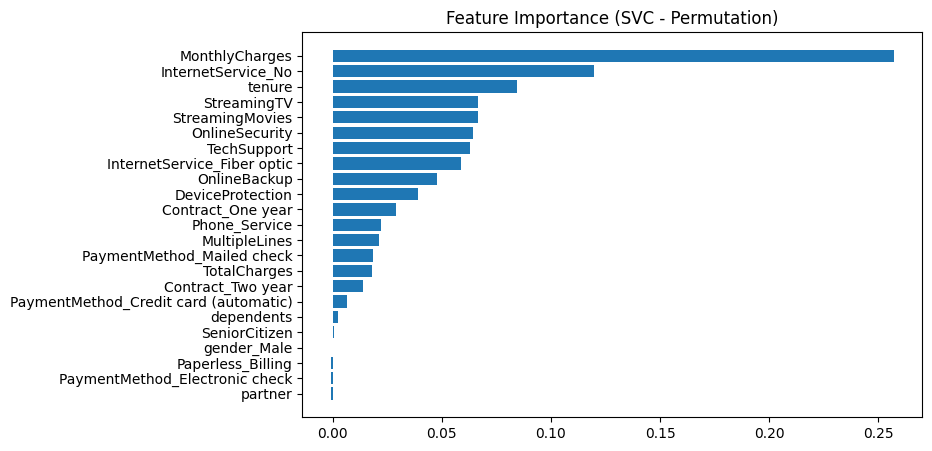

In [122]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

result = permutation_importance(
    svc_tuned_model, x_test, y_test, n_repeats=10, random_state=42
)

importance = result.importances_mean

# Create DataFrame
feat_imp = pd.DataFrame({
    'Feature': x_test.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (SVC - Permutation)")
plt.show()

**Monthly charges is the important feature in SVC**